[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


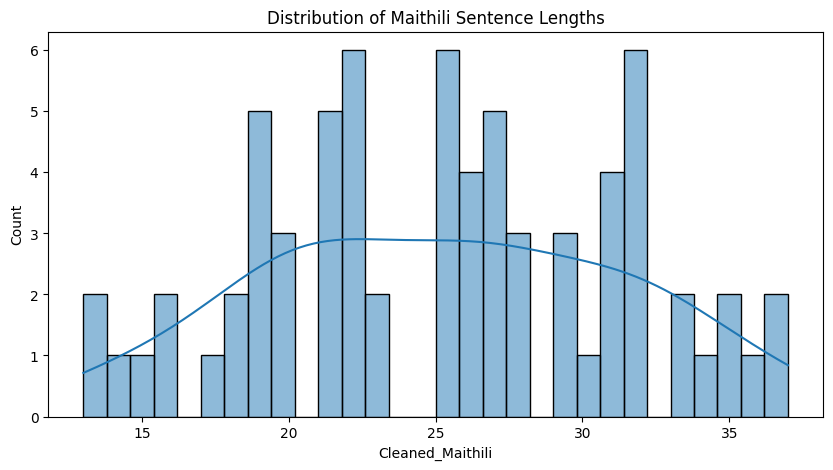

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.1310 - loss: 4.7750 - val_accuracy: 0.4786 - val_loss: 4.7492
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.4539 - loss: 4.7445 - val_accuracy: 0.4786 - val_loss: 4.7075
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.4591 - loss: 4.7001 - val_accuracy: 0.4786 - val_loss: 4.6425
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.4393 - loss: 4.6341 - val_accuracy: 0.4786 - val_loss: 4.5399
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.4455 - loss: 4.5272 - val_accuracy: 0.4786 - val_loss: 4.3789
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.4580 - loss: 4.3566 - val_accuracy: 0.4786 - val_loss: 4.1380
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.4435 - loss: 4.1315 - val_accuracy: 0.4786 - val_loss: 3.8175
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.4455 - loss: 3.8230 - val_accuracy: 0.4786 - val_loss: 3.4682
Epoch

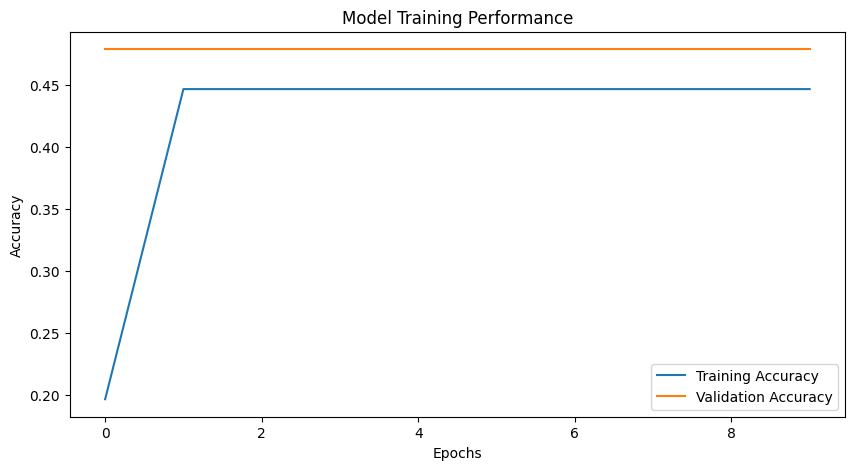

Dataset loaded from corrected_maithili_english_dataset.csv and processed successfully.


In [4]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, TimeDistributed
import numpy as np

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

# Step 1: Load Dataset from CSV
dataset_filename = "corrected_maithili_english_dataset.csv"
df = pd.read_csv(dataset_filename)

# Step 2: Data Preprocessing
def clean_text(text):
    """Remove special characters and convert text to lowercase."""
    text = re.sub(r'[^a-zA-Zऀ-ॿ\s]', '', str(text))  # Retain English and Devanagari characters
    text = text.lower().strip()
    return text

df['Cleaned_Maithili'] = df['Maithili'].apply(clean_text)
df['Cleaned_English'] = df['English'].apply(clean_text)

# Visualizing Data Cleaning
plt.figure(figsize=(10,5))
sns.histplot(df['Cleaned_Maithili'].str.len(), bins=30, kde=True)
plt.title("Distribution of Maithili Sentence Lengths")
plt.show()

# Step 3: Data Splitting
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

# Step 4: Tokenization and Sequence Padding
max_words = 10000  # Vocabulary size
max_length = 10  # Maximum length of a sentence

# Tokenizing Maithili and English sentences
maithili_tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
english_tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")

maithili_tokenizer.fit_on_texts(train_data['Cleaned_Maithili'])
english_tokenizer.fit_on_texts(train_data['Cleaned_English'])

train_maithili_sequences = maithili_tokenizer.texts_to_sequences(train_data['Cleaned_Maithili'])
test_maithili_sequences = maithili_tokenizer.texts_to_sequences(test_data['Cleaned_Maithili'])

train_english_sequences = english_tokenizer.texts_to_sequences(train_data['Cleaned_English'])
test_english_sequences = english_tokenizer.texts_to_sequences(test_data['Cleaned_English'])

train_maithili_padded = pad_sequences(train_maithili_sequences, maxlen=max_length, padding='post')
test_maithili_padded = pad_sequences(test_maithili_sequences, maxlen=max_length, padding='post')

train_english_padded = pad_sequences(train_english_sequences, maxlen=max_length, padding='post')
test_english_padded = pad_sequences(test_english_sequences, maxlen=max_length, padding='post')

# Step 5: Model Building
model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_length),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32, return_sequences=True)),
    TimeDistributed(Dense(len(english_tokenizer.word_index) + 1, activation='softmax'))
])

# Step 6: Model Compilation
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Convert targets to categorical for sequence prediction
def to_categorical_labels(sequences, vocab_size):
    categorical = np.zeros((len(sequences), max_length, vocab_size))
    for i, seq in enumerate(sequences):
        for t, word in enumerate(seq):
            categorical[i, t, word] = 1
    return categorical

train_english_categorical = to_categorical_labels(train_english_padded, len(english_tokenizer.word_index) + 1)
test_english_categorical = to_categorical_labels(test_english_padded, len(english_tokenizer.word_index) + 1)

# Step 7: Model Training
history = model.fit(train_maithili_padded, train_english_categorical,
                    epochs=10, validation_data=(test_maithili_padded, test_english_categorical))

# Step 8: Model Evaluation
loss, accuracy = model.evaluate(test_maithili_padded, test_english_categorical)
print(f'Test Accuracy: {accuracy}')

# Plot Training History
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Training Performance")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

print(f"Dataset loaded from {dataset_filename} and processed successfully.")
